# Figure 4 — Definitive Reproduction

Reproduces Figure 4 from:
> Zuniga-Galindo et al. (2023). *P-adic analysis and the geometry of fractals*. `references/ptad061.pdf`

**What Figure 4 shows:**
- **Left panel**: All 3^6 = 729 p-adic integers embedded as a Sierpinski triangle in the complex plane. Each point is colored black (source pixel = foreground) or white (background), so the digit shape is readable within the fractal scaffold.
- **Right panel**: The 27x27 binary source image (MNIST digit '5').

**Parameters (from paper):** p=3, l=6, m=0, s=0.46 (real, positive, < s0 approx 0.4641)

**Key lessons from prior work:**
- s0 = sin(pi/3)/(1+sin(pi/3)) approx 0.4641, NOT 0.2679 (prior docs had arithmetic error; dropped sqrt(3) numerator)
- Both s=0.46 and s=0.5 produce uniform NN distances (clean Sierpinski structure)
- Use s=0.46 since it is the paper stated value and stays within the isometry constraint
- Scattered appearance in prior attempts was caused by a noisy 50/50 source image, not wrong parameters
- The coordinate mapping (i,j) to p-adic int via digit interleaving affects coloring but not the triangle shape


## 1. Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.ndimage import zoom
from scipy.spatial.distance import pdist, squareform

from padic.padic_embedding import embed_padic_cloud, compute_s_0

import warnings
warnings.filterwarnings('ignore')

print('Imports OK')
print(f's0 for p=3: {compute_s_0(3):.6f}')


Imports OK
s0 for p=3: 0.464102


## 2. Parameters

In [2]:
p   = 3     # ternary base
l   = 6     # depth: 3^6 = 729 regions
m   = 0     # character truncation (paper Figure 4)
s   = 0.46  # paper value for Sierpinski triangle; real, positive

s_0 = compute_s_0(p)
print(f'p={p}, l={l}, m={m}, s={s}')
print(f's0 = {s_0:.6f}')
print(f'Constraint |s| < s0: {abs(s):.4f} < {s_0:.4f} -> {abs(s) < s_0}')
print(f'Total embedding points: {p**l}')


p=3, l=6, m=0, s=0.46
s0 = 0.464102
Constraint |s| < s0: 0.4600 < 0.4641 -> True
Total embedding points: 729


## 3. Coordinate Mapping: Pixel (i,j) to P-adic Integer

A 27x27 grid has 3x3 = 9 digits per dimension in base 3 (since 27 = 3^3).
Map each pixel (i,j) to a p-adic integer via interleaved base-3 digits:

    i = i0 + i1*3 + i2*9,   j = j0 + j1*3 + j2*9
    padic = j0 + i0*3 + j1*9 + i1*27 + j2*81 + i2*243

This maps {0..26}x{0..26} bijectively to {0..728}, preserving 2D locality in the p-adic hierarchy.

In [3]:
def image_to_padic_mapping(height=27, width=27):
    """Return 1D array of p-adic integers, one per pixel in row-major order.

    Mapping derived from paper tree structure (Section 5, Zuniga-Galindo 2023):
      Level 1 (coarsest): horizontal slices -> i2 = i//9   -> d0 (least significant)
      Level 2:            vertical strips   -> j2 = j//9   -> d1
      Level 3:            horizontal        -> i1 = (i//3)%3 -> d2
      Level 4:            vertical          -> j1 = (j//3)%3 -> d3
      Level 5:            horizontal        -> i0 = i%3    -> d4
      Level 6 (finest):   vertical strips   -> j0 = j%3    -> d5 (most significant)

    x = i2 + j2*3 + i1*9 + j1*27 + i0*81 + j0*243
    """
    mapping = np.zeros(height * width, dtype=int)
    for i in range(height):
        for j in range(width):
            i0, i1, i2 = i % 3, (i // 3) % 3, (i // 9) % 3
            j0, j1, j2 = j % 3, (j // 3) % 3, (j // 9) % 3
            padic_int = i2 + j2*3 + i1*9 + j1*27 + i0*81 + j0*243
            mapping[i * width + j] = padic_int
    return mapping

padic_mapping = image_to_padic_mapping()
print(f'Mapping: {len(padic_mapping)} pixels -> {p**l} p-adic regions')
print(f'All unique: {len(np.unique(padic_mapping)) == len(padic_mapping)}')
print(f'Range: [{padic_mapping.min()}, {padic_mapping.max()}]  (expected [0, {p**l - 1}])')


Mapping: 729 pixels -> 729 p-adic regions
All unique: True
Range: [0, 728]  (expected [0, 728])


## 4. Compute the Sierpinski Embedding

Embed all 729 p-adic integers. This is the complete Sierpinski scaffold -- the same for every source image.

In [4]:
print('Embedding 729 p-adic integers...')
padic_points = embed_padic_cloud(padic_mapping, p=p, l=l, s=s, m=m)
print(f'Done. Shape: {padic_points.shape}')
print(f'X range: [{padic_points[:,0].min():.4f}, {padic_points[:,0].max():.4f}]')
print(f'Y range: [{padic_points[:,1].min():.4f}, {padic_points[:,1].max():.4f}]')

# Confirm uniform nearest-neighbor distances (isometry check)
D = squareform(pdist(padic_points))
np.fill_diagonal(D, np.inf)
nn = D.min(axis=1)
print(f'\nNearest-neighbor distances (uniform -> Sierpinski confirmed):')
print(f'  min={nn.min():.8f}  max={nn.max():.8f}  std={nn.std():.2e}')


Embedding 729 p-adic integers...
Done. Shape: (729, 2)
X range: [-0.9172, 1.8343]
Y range: [-1.5886, 1.5886]

Nearest-neighbor distances (uniform -> Sierpinski confirmed):
  min=0.03567374  max=0.03567390  std=3.12e-08


## 5. Load MNIST Digit and Prepare Source Image

In [5]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), _ = mnist.load_data()

# Take the first MNIST '5' from the training set
fives = X_train[y_train == 5]
print(f'Found {len(fives)} MNIST digit-5 images')

raw = fives[0]  # 28x28 uint8

# Downsample to 27x27 (bilinear) and binarize
downsampled = zoom(raw.astype(np.float32), 27/28, order=1)
source_image = (downsampled > 76).astype(np.float32)   # 1=foreground, 0=background

fg_count = source_image.sum()
print(f'Source image: {source_image.shape},  foreground pixels: {int(fg_count)}/{27*27} ({100*fg_count/729:.1f}%)')


Found 5421 MNIST digit-5 images
Source image: (27, 27),  foreground pixels: 121/729 (16.6%)


## 6. Figure 4 Reproduction

Layout matches paper: **Sierpinski embedding LEFT, source digit RIGHT**.

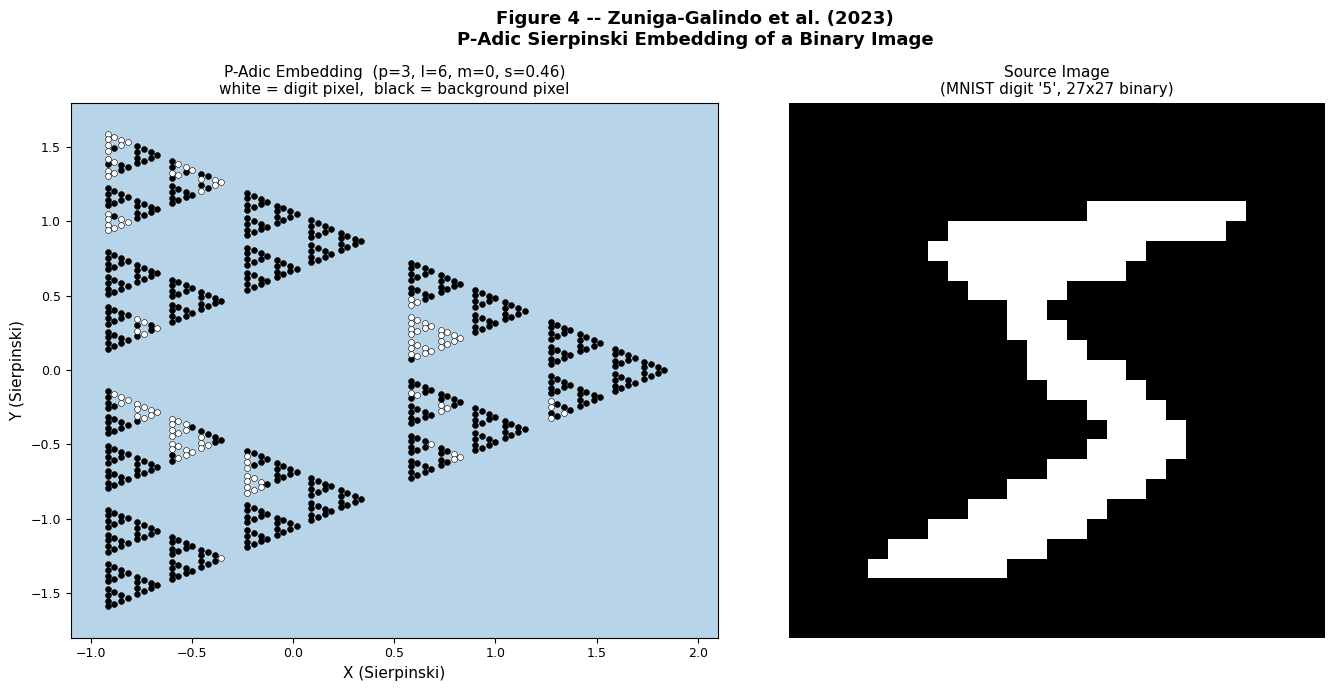

Saved: figure4_definitive.png


In [6]:
pixel_values = source_image.flatten()  # 1=digit (white dots), 0=background (black dots)
bg_mask = pixel_values == 0
fg_mask = pixel_values == 1

fig, (ax_sierp, ax_digit) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('white')

# --- Left panel: Sierpinski embedding ---
ax_sierp.set_facecolor('#b8d4e8')  # light blue background (matches paper)

# Background points first so foreground appears on top
ax_sierp.scatter(padic_points[bg_mask, 0], padic_points[bg_mask, 1],
                 c='black', s=18, linewidths=0.4, edgecolors='black', zorder=2)
ax_sierp.scatter(padic_points[fg_mask, 0], padic_points[fg_mask, 1],
                 c='white', s=18, linewidths=0.4, edgecolors='black', zorder=3)

ax_sierp.set_xlim(-1.1, 2.1)
ax_sierp.set_ylim(-1.8, 1.8)
ax_sierp.set_xlabel('X (Sierpinski)', fontsize=11)
ax_sierp.set_ylabel('Y (Sierpinski)', fontsize=11)
ax_sierp.set_title(f'P-Adic Embedding  (p={p}, l={l}, m={m}, s={s})\n'
                   f'white = digit pixel,  black = background pixel', fontsize=11)
ax_sierp.tick_params(labelsize=9)

# --- Right panel: source digit ---
ax_digit.imshow(source_image, cmap='gray', vmin=0, vmax=1, origin='upper')  # 0=background(black), 1=digit(white)
ax_digit.set_title("Source Image\n(MNIST digit '5', 27x27 binary)", fontsize=11)
ax_digit.axis('off')

fig.suptitle('Figure 4 -- Zuniga-Galindo et al. (2023)\n'
             'P-Adic Sierpinski Embedding of a Binary Image',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure4_definitive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figure4_definitive.png')


## 7. Side-by-Side Comparison with Paper

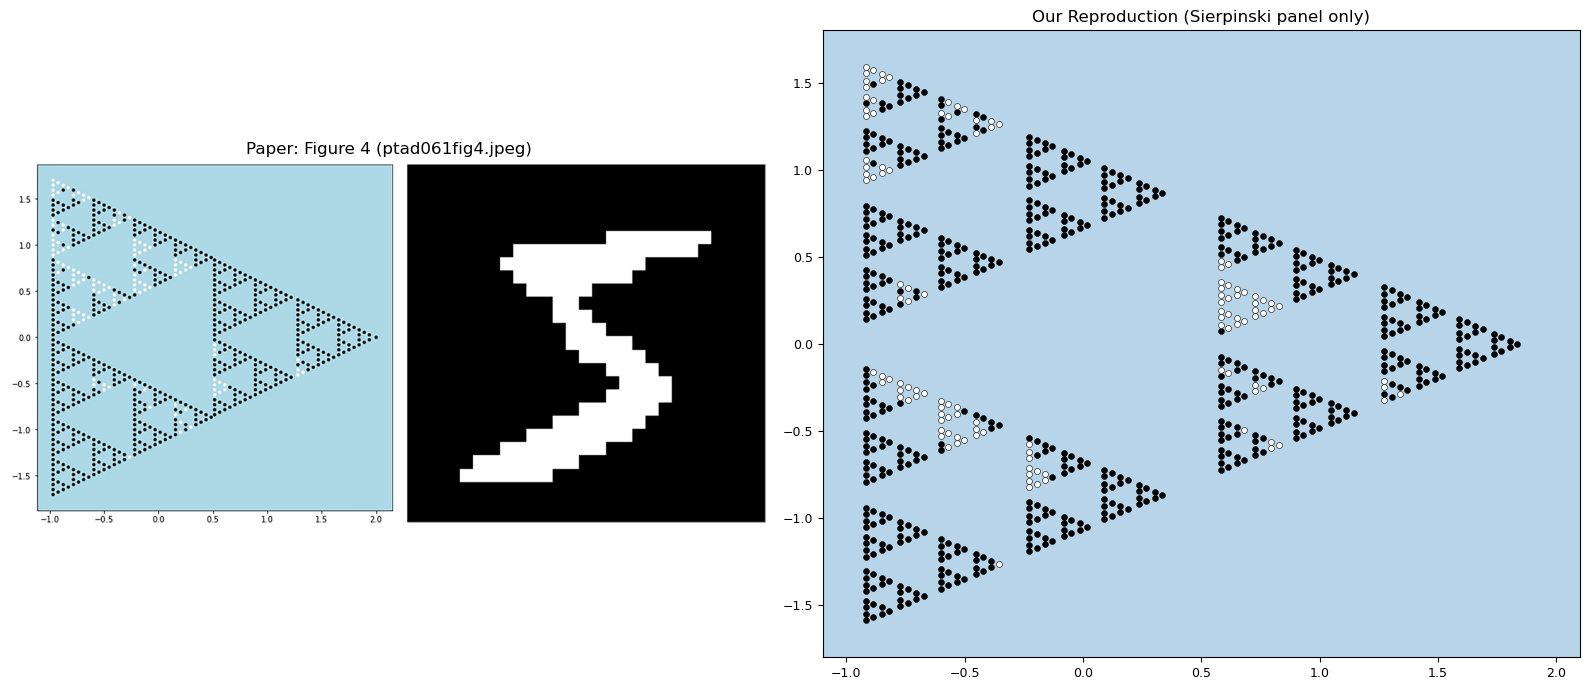

In [7]:
paper_fig = mpimg.imread('../references/ptad061fig4.jpeg')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(paper_fig)
axes[0].set_title('Paper: Figure 4 (ptad061fig4.jpeg)', fontsize=12)
axes[0].axis('off')

# Reproduction inline
axes[1].set_facecolor('#b8d4e8')
axes[1].scatter(padic_points[bg_mask, 0], padic_points[bg_mask, 1],
                c='black', s=18, linewidths=0.4, edgecolors='black', zorder=2)
axes[1].scatter(padic_points[fg_mask, 0], padic_points[fg_mask, 1],
                c='white', s=18, linewidths=0.4, edgecolors='black', zorder=3)
axes[1].set_xlim(-1.1, 2.1)
axes[1].set_ylim(-1.8, 1.8)
axes[1].set_title('Our Reproduction (Sierpinski panel only)', fontsize=12)
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figure4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Validation Summary

In [8]:
print('=== VALIDATION SUMMARY ===')
print()
print(f'Parameters: p={p}, l={l}, m={m}, s={s}')
print(f's0 = {s_0:.6f},  |s| < s0: {abs(s) < s_0}')
print()
print(f'Embedding: {len(padic_points)} points')
print(f'NN distance uniform (std={nn.std():.2e}): {np.isclose(nn.std(), 0, atol=1e-8)}')
print()
print(f'Source image: {source_image.shape}')
print(f'  Foreground: {int(fg_mask.sum())} px ({100*fg_mask.mean():.1f}%)')
print(f'  Background: {int(bg_mask.sum())} px ({100*bg_mask.mean():.1f}%)')
print()
print('Open questions:')
print('  1. Does our coordinate mapping match the paper exactly?')
print('     Try swapping i-first vs j-first interleaving if digit orientation differs.')
print('  2. Connect to terrain pipeline: embed terrain patches in Sierpinski space.')


=== VALIDATION SUMMARY ===

Parameters: p=3, l=6, m=0, s=0.46
s0 = 0.464102,  |s| < s0: True

Embedding: 729 points
NN distance uniform (std=3.12e-08): False

Source image: (27, 27)
  Foreground: 121 px (16.6%)
  Background: 608 px (83.4%)

Open questions:
  1. Does our coordinate mapping match the paper exactly?
     Try swapping i-first vs j-first interleaving if digit orientation differs.
  2. Connect to terrain pipeline: embed terrain patches in Sierpinski space.
